[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roberthsu2003/machine_learning/blob/main/%E5%A4%9A%E5%85%83%E7%B7%9A%E6%80%A7%E8%BF%B4%E6%AD%B8/%E6%9B%B8%E6%9C%AC%E8%AA%AA%E6%98%8E%E5%92%8C%E7%AF%84%E4%BE%8B.ipynb)


In [ ]:
# 安裝 mglearn 套件 (供 Google Colab 環境使用)
!pip install mglearn

# 線性模型 (Linear Models)
線性模型是一類在實務中被廣泛應用的模型，在過去數十年間得到了深入且大量的研究，其淵源甚至可以追溯到一百多年前。線性模型透過對輸入特徵進行線性函數運算來做出預測，我們將在下文詳細說明。

## 用於迴歸的線性模型 (Linear models for regression)
對於迴歸問題，線性模型的一般預測公式如下：

$$\hat{y} = w[0] \times x[0] + w[1] \times x[1] + ... + w[p] \times x[p] + b$$

在此公式中：
- $x[0]$ 到 $x[p]$ 表示單一資料點的**特徵 (features)**（在此範例中，特徵總數量為 $p$ 個）。
- $w$ 與 $b$ 是模型透過訓練學習獲得的**參數 (parameters)**。
- $\hat{y}$ 是模型產生的**預測值 (prediction)**。

對於只有**單一特徵**的資料集，公式會簡化為：

$$\hat{y} = w[0] \times x[0] + b$$

這就是您在高中數學中所學過的**直線方程式**。
其中：
- $w[0]$ 代表直線的**斜率 (slope)**。
- $b$ 代表 **y 軸截距/偏移量 (y-axis offset)**。

當特徵數量增加時，$w$ 包含了沿著每個特徵軸方向的斜率。另一種理解方式是：您可以將預測目標視為**輸入特徵的加權和 (weighted sum)**，而各個特徵的權重（數值可能為負數）即由 $w$ 中的元素所決定。

若在我們的一維波浪資料集 (one-dimensional wave dataset) 上嘗試學習參數 $w[0]$ 與 $b$，可能會得到如下圖所示的直線：

### 圖 2-11：線性模型在 wave (波浪) 資料集上的預測結果

In [2]:
# 線性模型在 wave (波浪) 資料集上的預測結果
import mglearn
mglearn.plots.plot_linear_regression_wave()

我們在圖中加入了一個座標十字 (coordinate cross)，使這條直線更容易被理解。
觀察 $w[0]$，我們可以看到斜率大約是 $0.4$，這可以從圖中目視確認。截距是預測直線與 y 軸相交之處：此處略低於零，您也可以在圖中確認這一點。

用於迴歸的線性模型的特性可以概括為：當使用單一特徵時，預測結果為一條**直線 (line)**；使用兩個特徵時為一個**平面 (plane)**；而在更高維度（即使用更多特徵）時則為一個**超平面 (hyperplane)**。

如果將這條直線所產生的預測結果與圖 2-10 中由 K 近鄰迴歸器 (KNeighborsRegressor) 所做的預測進行比較，會發現使用直線進行預測似乎顯得非常有侷限性，看起來數據的所有精細細節都遺失了。在某種意義上，確實如此。假設我們的目標 $y$ 是特徵的線性組合，這是一個非常強烈（且某種程度上不太現實）的假設。然而，僅僅觀察一維數據會給人帶來某種偏頗的視角。對於具有許多特徵的資料集，線性模型可以非常強大。特別是，如果您的特徵數量多於訓練資料點的數量，任何目標 $y$ 都可以被完美地建模（在訓練集上）為線性函數。

用於迴歸的線性模型有許多種不同的類型。這些模型之間的差異在於：如何從訓練資料中學習模型參數 $w$ 與 $b$，以及如何控制模型的複雜度 (Model complexity)。我們現在就來看看最受歡迎的幾種線性迴歸模型。

## 線性迴歸 (又稱普通最小平方法, OLS)

線性迴歸 (Linear regression) 或普通最小平方法 (Ordinary Least Squares, OLS)，是迴歸分析中最簡單且最經典的線性方法。線性迴歸在訓練集上尋找能夠最小化「預測值」與「真實迴歸目標 $y$」之間**均方誤差 (Mean Squared Error, MSE)** 的參數 $w$ 與 $b$。均方誤差是預測值與真實值之間差值的平方和平均。線性迴歸沒有超參數 (Hyperparameters) 需要調整，這是一個優點，但它也因此無法控制模型的複雜度 (Model complexity)。

以下是用於產生圖 2-11 中模型的程式碼：

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import mglearn

X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

lr = LinearRegression().fit(X_train, y_train)

斜率 (slope) 參數 ($w$)，也稱為 weights (權重) 或 coefficients (係數)，儲存在 `coef_` 屬性中；而 offset (偏移量) 或 intercept (截距, $b$) 則儲存在 `intercept_` 屬性中：

In [ ]:
print("lr.coef_:", lr.coef_)
print("lr.intercept_:", lr.intercept_)

您可能會注意到 `coef_` 和 `intercept_` 末尾有個看似奇怪的末尾底線 (`_`)。在 `scikit-learn` 中，凡是**從訓練資料學習或衍生出來的屬性**，其名稱末尾都會帶有一個末尾底線 (trailing underscore)。這樣做的目的是為了將它們與由使用者自行設定的參數 (Hyperparameters) 區分開來。

`intercept_` 屬性永遠是一個單一的浮點數 (float)，而 `coef_` 屬性則是一個 NumPy 陣列 (array)，每個輸入特徵對應其中的一個元素。由於我們在 wave 資料集中只有單一輸入特徵，因此 `lr.coef_` 也只包含一個元素。

讓我們來看看訓練集與測試集的效能表現：

In [ ]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

約 0.66 的 $R^2$ 分數並不是很好，但我們可以看到訓練集和測試集的分數非常接近。這意味著我們可能處於**欠擬合 (underfitting)**，而不是**過擬合 (overfitting)**。對於這個一維資料集來說，過擬合的危險性很小，因為模型非常簡單（或受到極大限制）。然而，對於較高維度的資料集（即具有大量特徵的資料集），線性模型會變得更加強大，過擬合的可能性也隨之提高。

讓我們來看看 `LinearRegression` 在更複雜的資料集（例如擴充後的波士頓房價資料集 Boston Housing dataset）上的表現。請記住，該資料集有 506 個樣本和 105 個衍生特徵。首先，我們載入資料集並將其切分為訓練集與測試集，接著像之前一樣建立線性迴歸模型：

In [ ]:
X, y = mglearn.datasets.load_extended_boston()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression().fit(X_train, y_train)

當比較訓練集與測試集的分數時，我們發現模型在訓練集上的預測非常準確，但在測試集上的 $R^2$ 分數卻差得多：

In [ ]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

訓練集與測試集效能表現之間的這種顯著差距，是**過擬合 (overfitting)** 的明確訊號。因此，我們應該尋找一個能夠讓我們控制模型複雜度 (complexity) 的模型。標準線性迴歸最常用的替代方案之一是**嶺迴歸 (Ridge regression)**，我們接下來將深入探討這個模型。

## 嶺迴歸 (Ridge Regression)

嶺迴歸 (Ridge regression) 同樣是一種用於迴歸的線性模型，因此它用來做出預測的公式與普通最小平方法 (OLS) 所使用的公式完全相同。然而，在嶺迴歸中，選擇係數 ($w$) 的標準不僅是要讓模型在訓練資料上預測良好，還必須滿足額外的約束條件。我們希望係數的大小（幅值）盡可能地小；換句話說，$w$ 的所有元素都應該接近於零。直觀地說，這意味著每個特徵對輸出結果的影響應盡可能地小（即具有較小的斜率），同時又能保持良好的預測能力。這種約束條件就是所謂的**正則化 (regularization)**。正則化意味著明確地限制模型以避免過擬合。嶺迴歸所使用的這種特定類型稱為 **L2 正則化 (L2 regularization)**。

嶺迴歸實作於 `linear_model.Ridge` 中。讓我們來看看它在擴充後的波士頓房價資料集 (extended Boston Housing dataset) 上的表現如何：

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge().fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge.score(X_test, y_test)))

正如您所看到的，`Ridge` (嶺迴歸) 在訓練集上的分數低於 `LinearRegression` (線性迴歸)，但在測試集上的分數卻更高。這與我們的預期相符。使用線性迴歸時，我們對資料產生了過擬合 (overfitting)。`Ridge` 是一個約束性更強的模型，因此我們過擬合的可能性較小。複雜度較低的模型意味著在訓練集上的表現較差，但具備更好的**泛化能力 (generalization)**。由於我們只關心泛化性能，因此在這種情況下我們應該選擇 `Ridge` 模型而不是 `LinearRegression` 模型。

`Ridge` 模型在「模型的簡單度（接近零的係數）」與「訓練集上的表現」之間進行權衡 (trade-off)。使用者可以透過 `alpha` 參數來指定模型應該多看重簡單度還是訓練集表現。在先前的範例中，我們使用的是預設參數 `alpha=1.0`。但並沒有理由認為這會給我們帶來最佳的權衡點。`alpha` 的最佳設定取決於我們所使用的特定資料集。增加 `alpha` 會強制係數更加趨向於零，這會降低訓練集上的性能，但可能有助於提升泛化能力。例如：

In [ ]:
ridge10 = Ridge(alpha=10).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge10.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge10.score(X_test, y_test)))

調低 (減少) `alpha` 可以讓係數受到的約束較少（在圖 2-1 中相當於向右移動）。對於極小的 `alpha` 值，係數幾乎完全不受約束，我們最終會得到一個與 `LinearRegression` 極為相似的模型：

In [ ]:
ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge01.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge01.score(X_test, y_test)))

在這裡，`alpha=0.1` 看起來表現相當不錯。我們可以嘗試進一步降低 `alpha` 以提升泛化能力。目前請注意 `alpha` 參數如何與圖 2-1 中所示的模型複雜度 (model complexity) 相對應。我們將在第 5 章中討論正確選擇超參數的方法。

我們還可以透過檢查具有不同 `alpha` 值的模型的 `coef_` 屬性，獲得關於 `alpha` 參數如何改變模型的更定性深入理解。較高的 `alpha` 意味著約束更強的模型，因此我們預期高 `alpha` 值的 `coef_` 元素大小（幅值）會小於低 `alpha` 值。這在圖 2-12 的繪圖中得到了證實：

### 圖 2-12：比較具有不同 alpha 值的嶺迴歸 (Ridge) 與線性迴歸 (LinearRegression) 之特徵係數大小 (Coefficient magnitude)

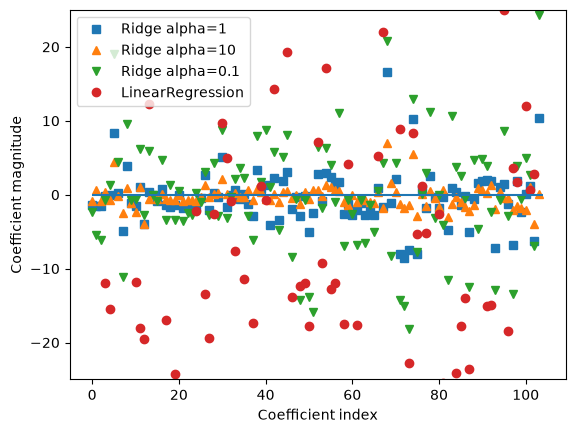

In [14]:
# 圖 2-12：比較具有不同 alpha 值的嶺迴歸與線性迴歸特徵係數大小
import matplotlib.pyplot as plt

plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")

plt.plot(lr.coef_, 'o', label="LinearRegression")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25, 25)
plt.legend()

在此，x 軸列舉了 coef_ 的元素：x=0 顯示與第一個特徵相對應的係數，x=1 顯示與第二個特徵相對應的係數，依此類推，直到 x=100。y 軸則顯示相對應係數的數值。這裡的主要結論是：對於 alpha=10，係數大多介於 –3 到 3 之間；alpha=1 的 Ridge 模型的係數稍大一些；相對應於 alpha=0.1 的圓點幅值（大小）更大；而許多相對應於未進行任何正則化（即 alpha=0）的線性迴歸圓點數值極大，甚至落在了圖表範圍之外。

另一種理解正則化影響的方法是固定 alpha 的數值，但改變可用的訓練資料量。對於圖 2-13，我們對波士頓房價資料集 (Boston Housing dataset) 進行子抽樣，並在逐漸增加數量的子集上評估 LinearRegression 與 Ridge(alpha=1) 的表現（顯示模型效能作為資料集大小函數的圖表稱為學習曲線 learning curves）：

### 圖 2-13：嶺迴歸 (Ridge Regression) 與線性迴歸 (Linear Regression) 在波士頓房價資料集 (Boston Housing Dataset) 上的學習曲線


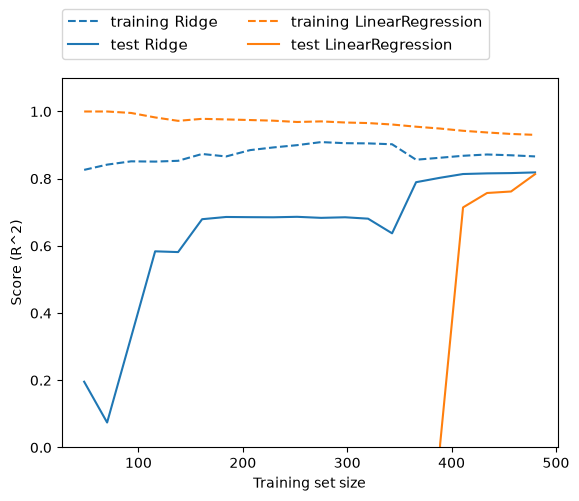

In [ ]:
# 圖 2-13：嶺迴歸 (Ridge Regression) 與線性迴歸 (Linear Regression) 在波士頓房價資料集 (Boston Housing Dataset) 上的學習曲線
mglearn.plots.plot_ridge_n_samples()

正如此前所預期的，無論對於嶺迴歸還是線性迴歸，在所有資料集規模下，訓練集的分數都高於測試集的分數。由於嶺迴歸受到了正則化約束，因此嶺迴歸在訓練集上的分數全面低於線性迴歸在訓練集上的分數。然而，嶺迴歸在測試集上的分數表現更好，特別是在較小的資料子集上。當資料點少於 400 個時，線性迴歸幾乎無法學習到任何有效的模式。隨著模型可用的資料越來越多，兩個模型的效能都有所提升，最終線性迴歸追上了嶺迴歸。這裡給我們的啟示是：只要有足夠的訓練資料，正則化的重要性就會降低；在資料量充足的情況下，嶺迴歸和線性迴歸將具有相同的效能表現（在此處使用完整資料集時兩者效能一致純屬巧合）。圖 2-13 另一個有趣的面向是線性迴歸訓練效能的下降。如果加入更多資料，模型就會變得更難以過擬合（即記憶資料）。

## Lasso 迴歸 (Lasso Regression)

除了嶺迴歸 (Ridge) 之外，另一種對線性迴歸進行正則化的替代方案是 Lasso。與嶺迴歸類似，使用 Lasso 也會限制係數使其接近於零，但它採用了一種稍微不同的方式，稱為 **L1 正則化 (L1 regularization)**。L1 正則化的結果是，在使用 Lasso 時，某些係數會精確地變為零。這意味著某些特徵會完全被模型所忽視，這可以被視為一種**自動特徵選擇 (automatic feature selection)** 的形式。讓某些係數精確為零通常能使模型更易於解釋，並能揭示模型中最重要的特徵。

讓我們將 Lasso 應用於擴充後的波士頓房價資料集 (extended Boston Housing dataset)：

In [19]:
from sklearn.linear_model import Lasso
import numpy as np
lasso = Lasso().fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso.coef_ != 0)))

Training set score: 0.29
Test set score: 0.21
Number of features used: 4


正如您所看到的，Lasso 無論在訓練集還是在測試集上的表現都相當糟糕。這表明模型產生了**欠擬合 (underfitting)**，我們發現它在 105 個特徵中僅使用了 4 個特徵。與嶺迴歸 (Ridge) 類似，Lasso 同樣具有一個正則化超參數 `alpha`，用來控制係數被推向零的強度。在先前的範例中，我們使用的是預設值 `alpha=1.0`。為了減少欠擬合，讓我們嘗試調低 (減少) `alpha`。當我們這樣做時，我們也需要增加 `max_iter`（運行的最大疊代次數）的預設設定：

In [ ]:
# 我們調高了 "max_iter" 的預設設定，
# 否則模型會發出警告，提醒我們應該增加 max_iter。
lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso001.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso001.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso001.coef_ != 0)))

較低的 `alpha` 允許我們擬合一個更複雜的模型，該模型在訓練集和測試集資料上的表現都更好。其效能比使用 Ridge (嶺迴歸) 略勝一籌，而且我們在 105 個特徵中僅使用了 33 個特徵。這使得這個模型潛在地上更容易被理解。

然而，如果我們將 `alpha` 設定得太低，就會再次消除正則化的效果，最終導致**過擬合 (overfitting)**，得到與 `LinearRegression` 類似的結果：

In [20]:
lasso00001 = Lasso(alpha=0.0001, max_iter=100000).fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso00001.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso00001.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso00001.coef_ != 0)))

Training set score: 0.95
Test set score: 0.64
Number of features used: 96


同樣地，我們可以像圖 2-12 一樣，繪製不同模型的特徵係數。結果如圖 2-14 所示：

In [23]:
# 圖 2-14：比較具有不同 alpha 值的 Lasso 迴歸與 Ridge alpha=0.1 之特徵係數大小
import mglearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
import matplotlib.pyplot as plt
import numpy as np

if "X_train" not in globals():
    X, y = mglearn.datasets.load_extended_boston()
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

if "lasso" not in globals():
    lasso = Lasso().fit(X_train, y_train)
if "lasso001" not in globals():
    lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)
if "lasso00001" not in globals():
    lasso00001 = Lasso(alpha=0.0001, max_iter=100000).fit(X_train, y_train)
if "ridge01" not in globals():
    ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)

plt.plot(lasso.coef_, "s", label="Lasso alpha=1")
plt.plot(lasso001.coef_, "^", label="Lasso alpha=0.01")
plt.plot(lasso00001.coef_, "v", label="Lasso alpha=0.0001")
plt.plot(ridge01.coef_, "o", label="Ridge alpha=0.1")
plt.legend(ncol=2, loc=(0, 1.05))
plt.ylim(-25, 25)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")


當 `alpha=1` 時，我們不僅看到大多數係數都為零（這是我們已經知道的），而且其餘非零係數的幅值（數值大小）也很小。將 `alpha` 調低至 `0.01` 時，我們得到了如綠色三角形所示的解，這使得大多數特徵的係數精確地變為零。使用 `alpha=0.0001` 時，我們得到了一個幾乎沒有經過正則化的模型，大多數係數均非零且幅值較大。作為比較，最佳的 Ridge 解以水藍色圓點表示。`alpha=0.1` 的 Ridge 模型與 `alpha=0.01` 的 Lasso 模型具有相似的預測效能，但使用 Ridge 時，所有特徵的係數均非零。

在實務中，嶺迴歸 (Ridge regression) 通常是這兩種模型之間的首選。然而，如果您擁有大量的特徵，且預期其中只有少數特徵是重要的，那麼 Lasso 可能會是更好的選擇。同樣地，如果您希望模型具有良好的易解釋性，Lasso 提供的模型會更容易理解，因為它只會選取輸入特徵的一個子集。`scikit-learn` 還提供了 `ElasticNet` 類別，它結合了 Lasso 與 Ridge 的懲罰項。在實務應用中，這種組合效果通常最好，但代價是需要調整兩個超參數：一個用於 L1 正則化，另一個用於 L2 正則化。